In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

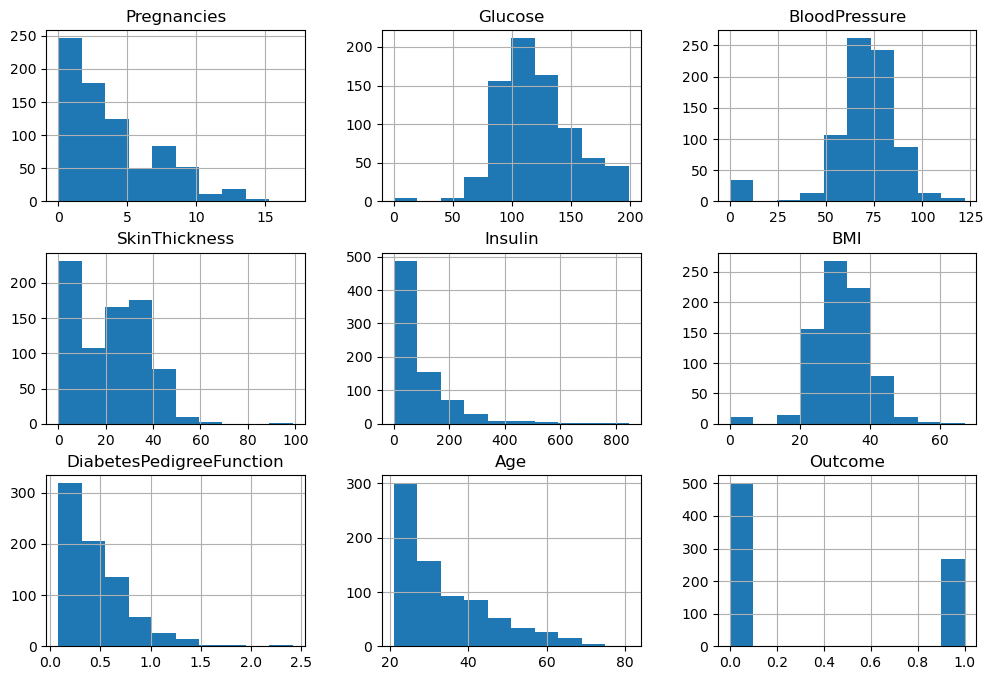

In [7]:
df.hist(figsize=(12,8))
plt.show()

The histograms show the distribution of each feature in the dataset.  
Glucose, BMI, and Age appear slightly right-skewed.  
Insulin shows strong skewness and contains extreme values.  
The Outcome variable is binary, representing diabetic (1) and non-diabetic (0) cases.

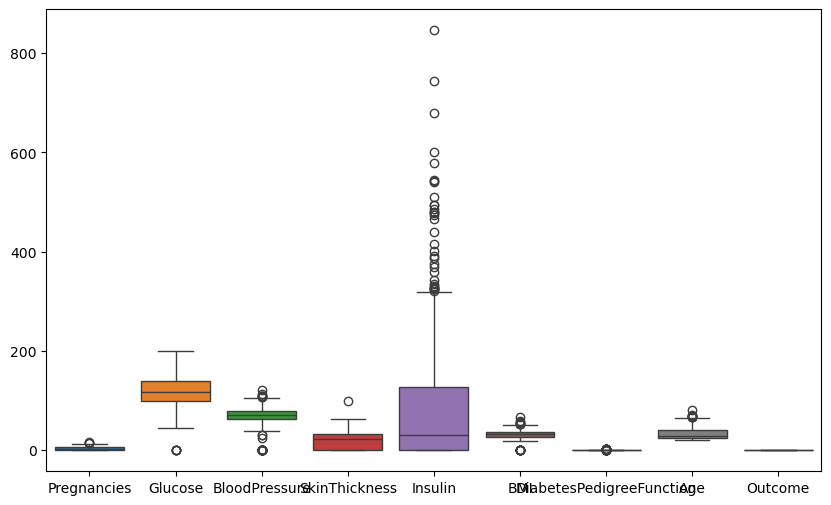

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

The boxplots highlight the presence of outliers in several variables.  
Insulin and SkinThickness contain significant outliers compared to other features.  
Glucose and BMI show moderate spread across observations.  
Outliers indicate potential extreme patient measurements in the dataset.

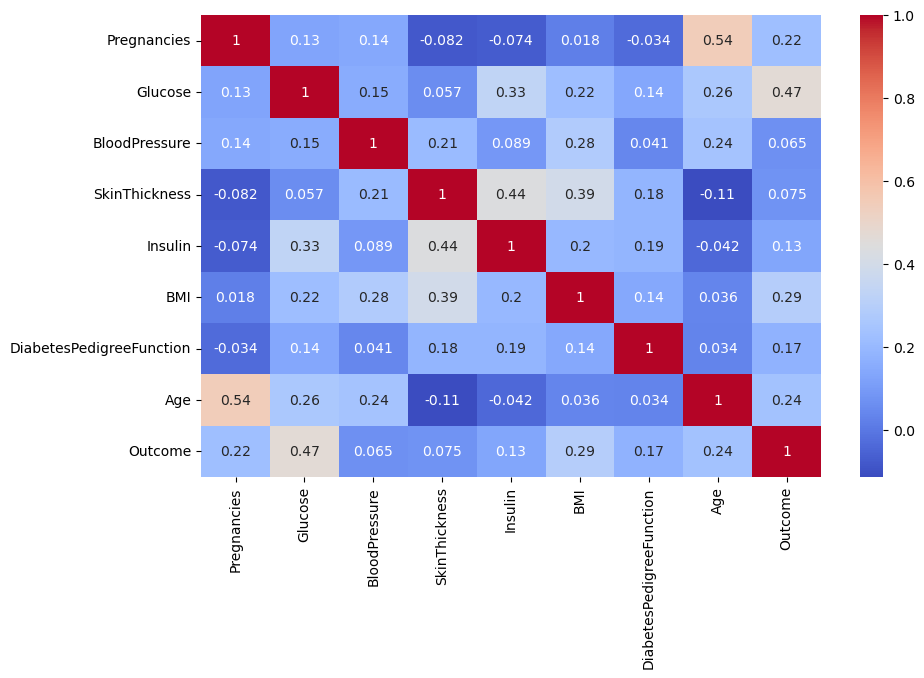

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

The heatmap shows correlation relationships between features.  
Glucose has the strongest positive correlation with the Outcome variable.  
BMI and Age also show moderate correlation with diabetes outcome.  
Most other variables show weak relationships with the target variable.

In [11]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

df[cols] = df[cols].fillna(df[cols].median())

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [18]:
y_pred = model.predict(X_test_scaled)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



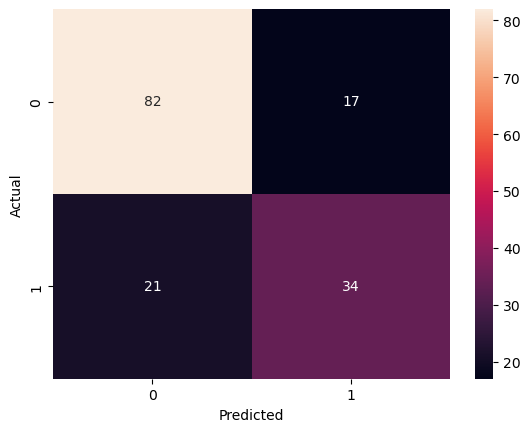

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

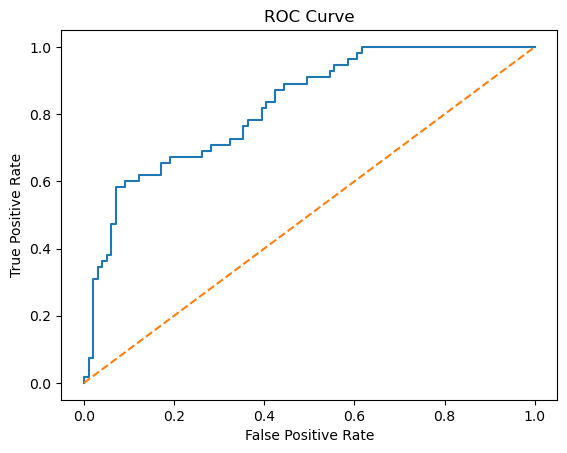

AUC Score: 0.82277318640955


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [24]:
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coeff)

                    Feature  Coefficient
0               Pregnancies     0.222978
1                   Glucose     1.102682
2             BloodPressure    -0.151540
3             SkinThickness     0.068836
4                   Insulin    -0.138252
5                       BMI     0.688839
6  DiabetesPedigreeFunction     0.203635
7                       Age     0.392410


In [26]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [1]:
import os
os.getcwd()

'C:\\Users\\ASUS\\DS Assignments\\Logistic_Regression'

### Model Deployment

The trained Logistic Regression model was deployed using Streamlit.
A Streamlit application (app.py) was created to take user inputs
such as pregnancies, glucose level, BMI, age, etc., and predict
whether a patient is likely to have diabetes.

The model was saved using pickle and loaded inside the Streamlit
application to generate predictions interactively.

Local URL: http://localhost:8501

# Interview Questions

## 1. What is the difference between Precision and Recall?

### Precision
Precision measures how many predicted positive values are actually positive.

Formula:

Precision = TP / (TP + FP)

- High precision means fewer false positives.

### Recall
Recall measures how many actual positive values are correctly predicted.

Formula:

Recall = TP / (TP + FN)

- High recall means fewer false negatives.

---

## 2. What is Cross-Validation and why is it important in binary classification?

Cross-validation is a technique used to evaluate model performance by dividing the dataset into multiple subsets.

The model is trained on some subsets and tested on the remaining subset multiple times.

### Importance:
- Helps reduce overfitting
- Provides better model evaluation
- Improves model generalization
- Ensures stable performance on unseen data

## Business Use Cases of Logistic Regression

Logistic Regression is widely used in:
- Spam email detection
- Disease prediction
- Customer churn prediction
- Loan approval prediction
- Fraud detection